In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Dataset1.csv")

df.drop("EmployeeID", axis=1, inplace=True)

X = df.drop("Attrition", axis=1)
y = df["Attrition"]
df

,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,51,Marketing,4,28,14510,4,1,No,14.0,No,3,17,No
9996,22,Engineering,1,0,5659,3,3,Yes,25.3,No,3,19,Yes
9997,30,Sales,1,0,4223,3,4,Yes,15.8,No,2,20,No
9998,42,Engineering,2,2,7990,5,3,No,5.7,No,3,25,No


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=42,stratify=y)

print(X_train.shape, X_test.shape)

(7500, 12) (2500, 12)


In [6]:
cat_cols = ['Department', 'OverTime', 'PromotionLast5Years', 'Attrition']

le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)   
y_test  = le_target.transform(y_test)

le = LabelEncoder()

for col in ['Department', 'OverTime', 'PromotionLast5Years']:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])  

num_cols = ['Age', 'JobLevel', 'YearsAtCompany', 'MonthlyIncome',
            'JobSatisfaction', 'WorkLifeBalance', 'DistanceFromHome',
            'PerformanceRating', 'TrainingHoursLastYear']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Encoding & scaling done!")

Encoding & scaling done!


In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(kernel='rbf', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

print("\nSummary of accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")


Logistic Regression
Accuracy: 0.9096
              precision    recall  f1-score   support

        Stay       0.91      1.00      0.95      2274
       Leave       0.00      0.00      0.00       226

    accuracy                           0.91      2500
   macro avg       0.45      0.50      0.48      2500
weighted avg       0.83      0.91      0.87      2500



c:\users\aik\appdata\local\programs\python\python37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\aik\appdata\local\programs\python\python37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\aik\appdata\local\programs\python\python37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier


Decision Tree
Accuracy: 0.8308
              precision    recall  f1-score   support

        Stay       0.92      0.90      0.91      2274
       Leave       0.14      0.16      0.15       226

    accuracy                           0.83      2500
   macro avg       0.53      0.53      0.53      2500
weighted avg       0.84      0.83      0.84      2500


Random Forest
Accuracy: 0.9092
              precision    recall  f1-score   support

        Stay       0.91      1.00      0.95      2274
       Leave       0.33      0.00      0.01       226

    accuracy                           0.91      2500
   macro avg       0.62      0.50      0.48      2500
weighted avg       0.86      0.91      0.87      2500


SVM
Accuracy: 0.9096
              precision    recall  f1-score   support

        Stay       0.91      1.00      0.95      2274
       Leave       0.00      0.00      0.00       226

    accuracy                           0.91      2500
   macro avg       0.45      0.50      0.4

c:\users\aik\appdata\local\programs\python\python37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\aik\appdata\local\programs\python\python37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\aik\appdata\local\programs\python\python37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [9]:
pipe = Pipeline([
    ('scaler', StandardScaler()),              
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred_pipe = pipe.predict(X_test)
print("Pipeline Accuracy:", accuracy_score(y_test, y_pred_pipe))

Pipeline Accuracy: 0.9092


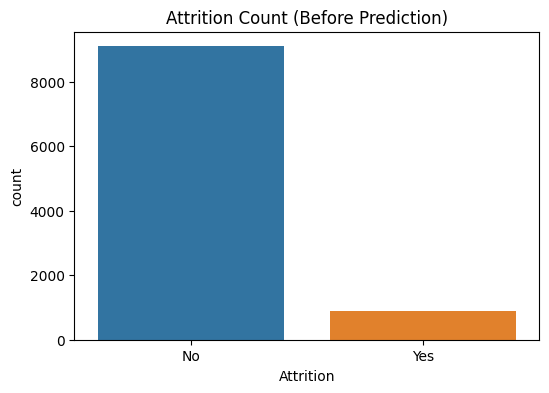

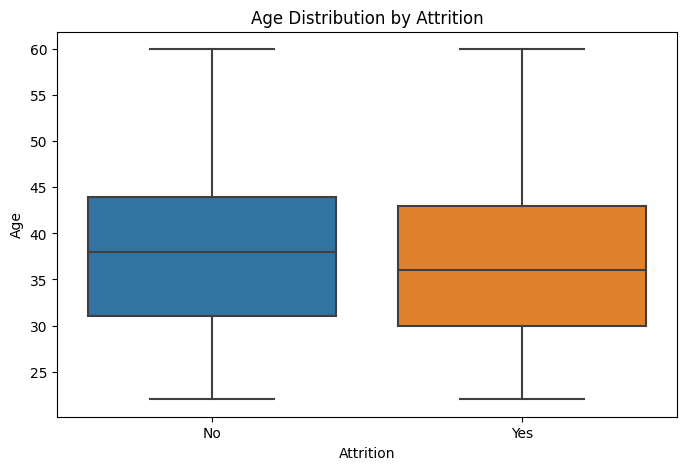

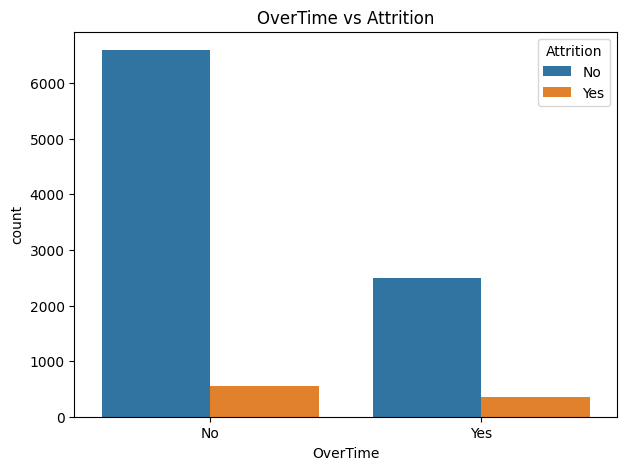

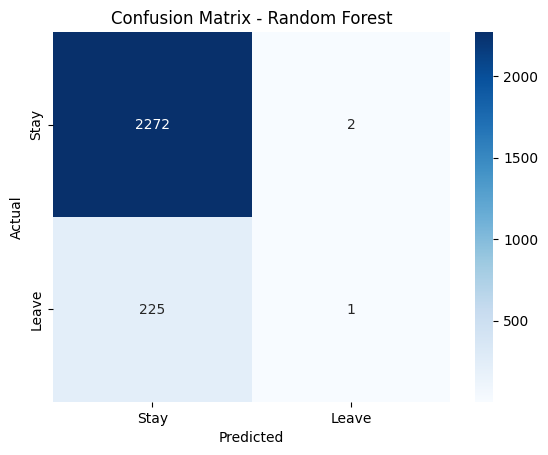

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Count (Before Prediction)")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title("Age Distribution by Attrition")
plt.show()

# 3. OverTime vs Attrition
plt.figure(figsize=(7,5))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("OverTime vs Attrition")
plt.show()

# 4. Confusion Matrix (after prediction - use best model)
cm = confusion_matrix(y_test, models['Random Forest'].predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Stay','Leave'], yticklabels=['Stay','Leave'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()